<p style="text-align:center">
    <a href="https://skills.network/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDA0321ENSkillsNetwork928-2022-01-01" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Hands-on Lab : Web Scraping**


Estimated time needed: **30 to 45** minutes


## Objectives


In this lab you will perform the following:


* Extract information from a given web site 
* Write the scraped data into a csv file.


## Extract information from the given web site
You will extract the data from the below web site: <br> 


In [1]:
#this url contains the data you need to scrape
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DA0321EN-SkillsNetwork/labs/datasets/Programming_Languages.html"

The data you need to scrape is the **name of the programming language** and **average annual salary**.<br> It is a good idea to open the url in your web broswer and study the contents of the web page before you start to scrape.


Import the required libraries


In [2]:
# Your code here
from bs4 import BeautifulSoup
import requests
import pandas as pd

Download the webpage at the url


In [3]:
#your code goes here
data_1 = requests.get(url).text

Create a soup object


In [4]:
#your code goes here
soup = BeautifulSoup(data_1,"html.parser")

Scrape the `Language name` and `annual average salary`.


In [16]:
#your code goes here
table = soup.find('table')
languages_list = []

for row in table.find_all('tr'):
    cols = row.find_all('td')
    Language = cols[1].getText()
    Average_Annual_Salary = cols[3].getText()
    languages_list.append([Language, Average_Annual_Salary])

    print(Language, ',', Average_Annual_Salary)

Language , Average Annual Salary
Python , $114,383
Java , $101,013
R , $92,037
Javascript , $110,981
Swift , $130,801
C++ , $113,865
C# , $88,726
PHP , $84,727
SQL , $84,793
Go , $94,082


Save the scrapped data into a file named *popular-languages.csv*


In [17]:
# your code goes here

df = pd.DataFrame(languages_list[1:], columns=["Language", "Average Annual Salary"])

# Save to CSV
df.to_csv('popular-languages.csv', index=False)

print("File 'popular-languages.csv' created successfully!")

File 'popular-languages.csv' created successfully!


In [18]:
print(pd.read_csv('popular-languages.csv'))

     Language Average Annual Salary
0      Python              $114,383
1        Java              $101,013
2           R               $92,037
3  Javascript              $110,981
4       Swift              $130,801
5         C++              $113,865
6          C#               $88,726
7         PHP               $84,727
8         SQL               $84,793
9          Go               $94,082


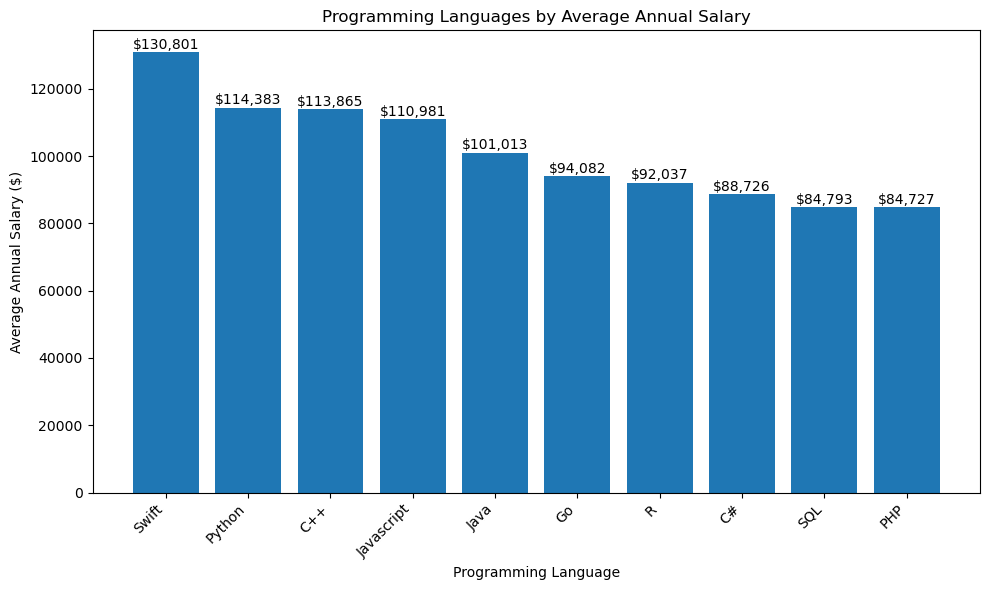

In [26]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load your data
df = pd.read_csv('popular-languages.csv')

# 2. RECTIFICATION: Clean the salary column
# This removes $ and commas so Python can treat them as numbers (floats)
df['Average Annual Salary'] = df['Average Annual Salary'].replace('[\$,]', '', regex=True).astype(float)

# 3. Sort in descending order
df_sorted = df.sort_values(by='Average Annual Salary', ascending=False)

# 4. Create the chart
plt.figure(figsize=(10, 6))
# Using a color like 'skyblue' makes it more readable than the default blue
plt.bar(df_sorted['Language'], df_sorted['Average Annual Salary'])

plt.xlabel('Programming Language')
plt.ylabel('Average Annual Salary ($)')
plt.title('Programming Languages by Average Annual Salary')
plt.xticks(rotation=45, ha='right')

# 5. Add currency labels on top of the bars
for i, v in enumerate(df_sorted['Average Annual Salary']):
    plt.text(i, v + 1000, f"${int(v):,}", ha='center')

# Show the plot
plt.tight_layout()
plt.show()


## Authors


Ramesh Sannareddy


### Other Contributors


Rav Ahuja


## Change Log


|  Date (YYYY-MM-DD) |  Version | Changed By  |  Change Description |
|---|---|---|---|
| 2020-10-17  | 0.1  | Ramesh Sannareddy  |  Created initial version of the lab |


 Copyright &copy; 2020 IBM Corporation. This notebook and its source code are released under the terms of the [MIT License](https://cognitiveclass.ai/mit-license/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDA0321ENSkillsNetwork928-2022-01-01).
